<a href="https://colab.research.google.com/github/viviantram03/labb-1/blob/main/labaml3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import math
import random
import string
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score


In [ ]:
def prepare_sequence(seq, to_ix):
  idxs = [to_ix.get(w, 0) for w in seq]
  return torch.tensor(idxs, dtype=torch.long)

training_data = [
    ("The dog ate the apple".split(), ["DET", "NN", "V", "DET", "NN"]),
    ("Everybody read that book".split(), ["NN", "V", "DET", "NN"]),
    ("Everybody does machine learning nowadays".split(), ["NN", "V", "NN", "NN", "ADV"])
]

word_to_ix = {}
for sent, tags in training_data:
  for word in sent:
    if word not in word_to_ix:
      word_to_ix[word] = len(word_to_ix)
tag_to_ix = {"DET": 0, "NN": 1, "V": 2, "ADV": 3}

EMBEDDING_DIM = 6
HIDDEN_DIM = 12
VOCAB_SIZE = len(word_to_ix)
TAGSET_SIZE = len(tag_to_ix)

class RNNTagger(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, vocab_size, tagset_size):
      super(RNNTagger, self).__init__()
      self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
      self.rnn = nn.RNN(embedding_dim, hidden_dim)
      self.hidden2tag = nn.Linear(hidden_dim, tagset_size)

    def forward(self, sentence):
      embeds = self.word_embeddings(sentence)
      out, _ = self.rnn(embeds.view(len(sentence), 1, -1))
      tag_space = self.hidden2tag(out.view(len(sentence), -1))
      return F.log_softmax(tag_space, dim=1)

class LTSMTagger(nn.Module):
  def __init__(self, embedding_dim, hidden_dim, vocab_size, tagset_size):
    super(LTSMTagger, self).__init__()
    self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
    self.lstm = nn.LSTM(embedding_dim, hidden_dim)
    self.hidden2tag = nn.Linear(hidden_dim, tagset_size)

  def forward(self, sentence):
    embeds = self.word_embeddings(sentence)
    out, _ = self.lstm(embeds.view(len(sentence), 1, -1))
    tag_space = self.hidden2tag(out.view(len(sentence), -1))
    return F.log_softmax(tag_space, dim=1)

class GRUTagger(nn.Module):
  def __init__(self, embedding_dim, hidden_dim, vocab_size, tagset_size):
    super(GRUTagger, self).__init__()
    self.word_embeddings = nn.Embedding(vocab_size, embedding_dim)
    self.gru = nn.GRU(embedding_dim, hidden_dim)
    self.hidden2tag = nn.Linear(hidden_dim, tagset_size)

  def forward(self, sentence):
    embeds = self.word_embeddings(sentence)
    out, _ = self.gru(embeds.view(len(sentence), 1, -1))
    tag_space = self.hidden2tag(out.view(len(sentence), -1))
    return F.log_softmax(tag_space, dim=1)

def train_and_evaluate(model, name, epochs=100):
  loss_function = nn.NLLLoss()
  optimizer = optim.SGD(model.parameters(), lr=0.1)

  for epoch in range(epochs):
    epoch_loss = 0
    for sentence, tags in training_data:
      model.zero_grad()
      sentence_in = prepare_sequence(sentence, word_to_ix)
      targets = prepare_sequence(tags, tag_to_ix)
      tag_scores = model(sentence_in)
      loss = loss_function(tag_scores, targets)
      loss.backward()
      optimizer.step()
      epoch_loss += loss.item()

  avg_loss = epoch_loss / len(training_data)
  perplexity = math.exp(avg_loss)

  print(f"Model: {name:4} | Final Loss: {avg_loss:.4f} | Perplexity: {perplexity:.4f}")

print("--- Task 1: Compare RNN, LSTM and GRU ---")
train_and_evaluate(RNNTagger(EMBEDDING_DIM, HIDDEN_DIM, VOCAB_SIZE, TAGSET_SIZE), "RNN")
train_and_evaluate(LTSMTagger(EMBEDDING_DIM, HIDDEN_DIM, VOCAB_SIZE, TAGSET_SIZE), "LSTM")
train_and_evaluate(GRUTagger(EMBEDDING_DIM, HIDDEN_DIM, VOCAB_SIZE, TAGSET_SIZE), "GRU")



--- Task 1: Compare RNN, LSTM and GRU ---
Model: RNN  | Final Loss: 0.0261 | Perplexity: 1.0265
Model: LSTM | Final Loss: 0.4342 | Perplexity: 1.5437
Model: GRU  | Final Loss: 0.1144 | Perplexity: 1.1212


In [ ]:

raw_text= """Long Short-Term Memory (LSTM) is a recurrent neural network (RNN) architecture that has been designed
to address the vanishing and exploding gradient problems of conventional RNNs. Unlike feedforward neural networks,
RNNs have cyclic connections making them powerful for modeling sequences.
They have been successfully used for sequence labeling and sequence prediction tasks,
such as handwriting recognition, language modeling, phonetic labeling of acoustic frames. However, in contrast to the deep neural
networks, the use of RNNs in speech recognition has been limited to phone recognition in small scale tasks.
In this paper, we present novel LSTM based RNN architectures which make more effective
use of model parameters to train acoustic models for large vocabulary speech recognition.
We train and compare LSTM, RNN and DNN models at various numbers of parameters and configurations.
We show that LSTM models converge quickly and give state of the art speech recognition performance for relatively small sized models.""".split()

vocab = set(raw_text)
vocab_size = len(vocab)
word_to_ix = {word: i for i, word in enumerate(vocab)}

CONTEXT_SIZE = 2
EMBED_DIM = 10

cbow_data = []
skipgram_data = []

for i in range(CONTEXT_SIZE, len(raw_text) - CONTEXT_SIZE):
  target = raw_text[i]
  context = [raw_text[i - j] for j in range(1, CONTEXT_SIZE + 1)] + [raw_text[i + j] for j in range(1, CONTEXT_SIZE + 1)]

  cbow_data.append((context, target))

  for w in context:
    skipgram_data.append((target, w))

class CBOW(nn.Module):
  def __init__(self, vocab_size, embed_dim, context_size):
    super(CBOW, self).__init__()
    self.embeddings = nn.Embedding(vocab_size, embed_dim)
    self.linear = nn.Linear((2*context_size)*embed_dim, vocab_size)

  def forward(self, inputs):
    embeds = (self.embeddings(inputs)).view(1, -1)
    out = self.linear(embeds)
    return nn.functional.log_softmax(out, dim=-1)

  def get_word_vector(self, word_idx):
    return self.embeddings(word_idx)

class SkipGram(nn.Module):
  def __init__(self, vocab_size, embed_dim):
    super(SkipGram, self).__init__()
    self.embeddings = nn.Embedding(vocab_size, embed_dim)
    self.linear = nn.Linear(embed_dim, vocab_size)

  def forward(self, target_word):
    embeds = self.embeddings(target_word)
    out = self.linear(embeds)
    return nn.functional.log_softmax(out, dim=-1)

  def get_word_vector(self, word_idx):
    return self.embeddings(word_idx)

model_cbow = CBOW(vocab_size, EMBED_DIM, CONTEXT_SIZE)
model_sg = SkipGram(vocab_size, EMBED_DIM)

optimizer_cbow = optim.SGD(model_cbow.parameters(), lr=0.01)
optimizer_sg = optim.SGD(model_sg.parameters(), lr=0.01)
loss_function = nn.NLLLoss()

print("--- Task 2: Training CBOW and SkipGram models ---")

for epoch in range(300):
  for context, target in cbow_data:
    context_idxs = torch.tensor([word_to_ix[w] for w in context], dtype=torch.long)
    model_cbow.zero_grad()
    loss = loss_function(model_cbow(context_idxs), torch.tensor([word_to_ix[target]], dtype=torch.long))
    loss.backward()
    optimizer_cbow.step()

  for target, context in skipgram_data:
    model_sg.zero_grad()
    loss = loss_function(model_sg(torch.tensor([word_to_ix[target]], dtype=torch.long)), torch.tensor([word_to_ix[context]], dtype=torch.long))

    loss.backward()
    optimizer_sg.step()

print("Training complete.")

def compare_similarity(word1, word2):
  w1_idx = torch.tensor([word_to_ix[word1]], dtype=torch.long)
  w2_idx = torch.tensor([word_to_ix[word2]], dtype=torch.long)

  cos = nn.CosineSimilarity(dim=0)

  sim_cbow = cos(model_cbow.get_word_vector(w1_idx).squeeze(), model_cbow.get_word_vector(w2_idx).squeeze()).item()
  sim_sg = cos(model_sg.get_word_vector(w1_idx).squeeze(), model_sg.get_word_vector(w2_idx).squeeze()).item()

  print(f"Similarity '{word1}' <-> '{word2}': | CBOW: {sim_cbow:.4f} | SkipGram: {sim_sg:.4f}")

print("--- Embedding Comparison ---")
compare_similarity("neural", "network")
compare_similarity("gradient", "problems")
compare_similarity("LSTM", "RNNs")




--- Task 2: Training CBOW and SkipGram models ---
Training complete.
--- Embedding Comparison ---
Similarity 'neural' <-> 'network': | CBOW: 0.3293 | SkipGram: 0.4071
Similarity 'gradient' <-> 'problems': | CBOW: -0.2501 | SkipGram: 0.6779
Similarity 'LSTM' <-> 'RNNs': | CBOW: 0.1723 | SkipGram: -0.1235


Loaded 1000 English and 1000 German sentences.

 --- Task 3: Training GRU Language Classifier ---
Epoch  5000 | Loss: 0.0000 | Ein schwarzer Mann und seine zwei weißen... -> German ✓
Epoch 10000 | Loss: 0.0000 | A professionally dressed woman standing ... -> English ✓
Epoch 15000 | Loss: 0.0000 | Ein Mann trägt eine große Ladung von Met... -> German ✓
Epoch 20000 | Loss: 0.0000 | Two men selling fruit at a fruit market.... -> English ✓

--- Evaluating Classifier Performance ---
Model Accuracy on 1000 random test samples:  100.00%


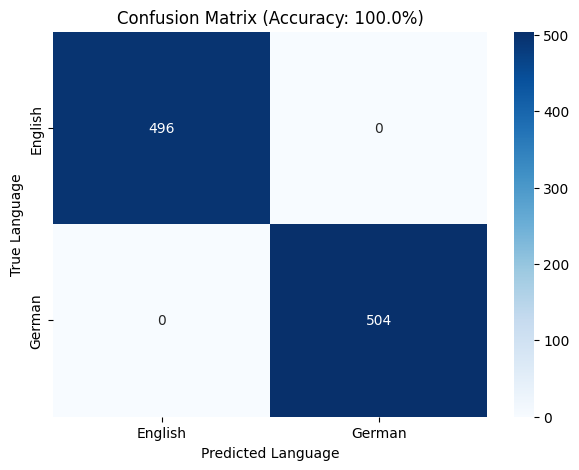

In [ ]:
def read_lines(filename):
  with open(filename, encoding='utf-8') as f:
    return [line.strip() for line in f if line.strip()]

try:
  dataset = {
      "English": read_lines("test_2016_flickr.en"),
      "German": read_lines("test_2016_flickr.de")
  }
  print(f"Loaded {len(dataset['English'])} English and {len(dataset['German'])} German sentences.")
except FileNotFoundError:
  print("Error: Could not find the dataset files.")
  dataset = {"English": ["Dummy english"], "German": ["Dummy german"]}

all_categories = list(dataset.keys())
n_categories = len(all_categories)

all_letters = string.ascii_letters + " .,;''-!äöüÄÖÜß"
n_letters = len(all_letters)


def letterToIndex(letter):
  return all_letters.find(letter)

def lineToTensor(line):
  tensor = torch.zeros(len(line), 1, n_letters)
  for li, letter in enumerate(line):
    idx = letterToIndex(letter)
    if idx != -1:
      tensor[li][0][idx] = 1
  return tensor

def randomTrainingExample():
  category = random.choice(all_categories)
  line = random.choice(dataset[category])
  category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long)
  line_tensor = lineToTensor(line)
  return category, line, category_tensor, line_tensor

class GRULanguageClassifier(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(GRULanguageClassifier, self).__init__()
    self.hidden_size = hidden_size
    self.gru = nn.GRU(input_size, hidden_size)
    self.fc = nn.Linear(hidden_size, output_size)
    self.softmax = nn.LogSoftmax(dim=1)

  def forward(self, input_line, hidden):
    out, hidden = self.gru(input_line, hidden)
    final_out = self.fc(out[-1])
    return self.softmax(final_out), hidden

  def initHidden(self):
    return torch.zeros(1, 1, self.hidden_size)

n_hidden = 128
model_clf = GRULanguageClassifier(n_letters, n_hidden, n_categories)
criterion = nn.NLLLoss()
learning_rate = 0.005
optimizer = torch.optim.Adam(model_clf.parameters(), lr=learning_rate)

print("\n --- Task 3: Training GRU Language Classifier ---")

epochs = 20000

for epoch in range(1, epochs + 1):
  category, line, category_tensor, line_tensor = randomTrainingExample()

  hidden = model_clf.initHidden()
  model_clf.zero_grad()

  output, hidden = model_clf(line_tensor, hidden)
  loss = criterion(output, category_tensor)

  loss.backward()
  optimizer.step()

  if epoch % 5000 == 0:
    guess_idx = output.topk(1)[1].item()
    guess = all_categories[guess_idx]
    correct = '✓' if guess == category else f'✗ (Correct: {category})'
    print(f"Epoch {epoch:5} | Loss: {loss.item():.4f} | {line[:40]:<40}... -> {guess} {correct}")

print("\n--- Evaluating Classifier Performance ---")
n_test_samples = 1000
y_true = []
y_pred = []

for _ in range(n_test_samples):
  category, line, category_tensor, line_tensor = randomTrainingExample()

  with torch.no_grad():
    hidden = model_clf.initHidden()
    output, _ = model_clf(line_tensor, hidden)
    topv, topi = output.topk(1, 1, True)
    guess_idx = topi[0][0].item()

  y_true.append(category)
  y_pred.append(all_categories[guess_idx])

accuracy = accuracy_score(y_true, y_pred)
print(f"Model Accuracy on {n_test_samples} random test samples: {accuracy * 100: .2f}%")

cm = confusion_matrix(y_true, y_pred, labels=all_categories)

plt.figure(figsize=(7, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=all_categories, yticklabels=all_categories)
plt.xlabel("Predicted Language")
plt.ylabel("True Language")
plt.title(f"Confusion Matrix (Accuracy: {accuracy*100:.1f}%)")
plt.show()